# Multivariate imputation

## 0. Import relevant modules

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import norm
from bayesdawn import datamodel, psdmodel, postprocess, noisegenerator

MLDC modules could not be loaded.
MLDC modules could not be loaded.
LISABeta could not be loaded.
MLDC modules could not be loaded.


## 1. Generate example data

We generate a multivariate, Gaussian stationary time series based on an arbitrary PSD-CSD matrix.

In [2]:
def multiple_dot(a_mat, b_mat):
    """
    Perform the matrix multiplication of two list of matrices.

    Parameters
    ----------
    a : ndarray
        series of m x n matrices (array of size p x m x n)
    b : ndarray
        series of n x k matrices (array of size p x n x k)

    Returns
    -------
    c : ndarray
        array of size p x m x k containg the dot products of all matrices
        contained in a and b.

    """
    return np.einsum("...jk, ...kl", a_mat, b_mat)

def psd_function(freq, f1=0.001, f2=0.002, f3=0.003, a1=1e4, a2=1e4, a3=1e4):
    """
    Your PSD function.

    Parameters
    ----------
    freq : ndarray
        Vector of frequency values in Hz.

    Returns
    -------
    psd : ndarray
        Vector of one-sided PSD values computed at freq, expressed in A^2 / Hz, where
        A is the physical unit of the considered time series quantity. 

    """
    xf = np.abs(freq)
    n_freq = len(xf)
    p = 3
    psd_matrix = np.zeros((n_freq, p, p), dtype=complex)

    # Replace zero frequency with a small value to avoid division by zero
    xf[xf == 0] = xf[1] / 10

    # Define the diagonal elements of the PSD matrix using the given formula
    lambda1 = 1/(1+a1/(1+(xf/f1)**(4/np.log10(5))))
    lambda2 = 1/(1+a2/(1+(xf/f2)**(4/np.log10(5))))
    lambda3 = 1/(1+a3/(1+(xf/f3)**(4/np.log10(5))))

    psd_matrix[:, 0, 0] = lambda1
    psd_matrix[:, 1, 1] = lambda2
    psd_matrix[:, 2, 2] = lambda3

    # Now define the complex off-diagonal elements to introduce correlations between the channels
    # For example, let's introduce some arbitrary correlations
    psd_matrix[:, 0, 1] = 0.5 * np.sqrt(lambda1 * lambda2) * np.exp(1j * np.pi / 4)
    psd_matrix[:, 1, 0] = np.conj(psd_matrix[:, 0, 1])  # Ensure Hermitian symmetry
    psd_matrix[:, 0, 2] = 0.3 * np.sqrt(lambda1 * lambda3) * np.exp(1j * np.pi / 6)
    psd_matrix[:, 2, 0] = np.conj(psd_matrix[:, 0, 2])  # Ensure Hermitian symmetry
    psd_matrix[:, 1, 2] = 0.4 * np.sqrt(lambda2 * lambda3) * np.exp(1j * np.pi / 3)
    psd_matrix[:, 2, 1] = np.conj(psd_matrix[:, 1, 2])  # Ensure Hermitian symmetry

    return psd_matrix

In [3]:
# Choose size of data
upscale_fac = 1
n_data = 2**14*upscale_fac
# Set sampling frequency
fs = 2e-1
# Evaluate the PSD function on a frequency grid twice the size of the data
n_psd = 2*n_data
frequencies = np.fft.fftfreq(n_psd, d=1/fs)
# Compute the PSD matrix for the given frequencies
a1 = 1e4
a2 = 2e4
a3 = 3e4
psd_matrix = psd_function(frequencies, a1=a1, a2=a2, a3=a3)

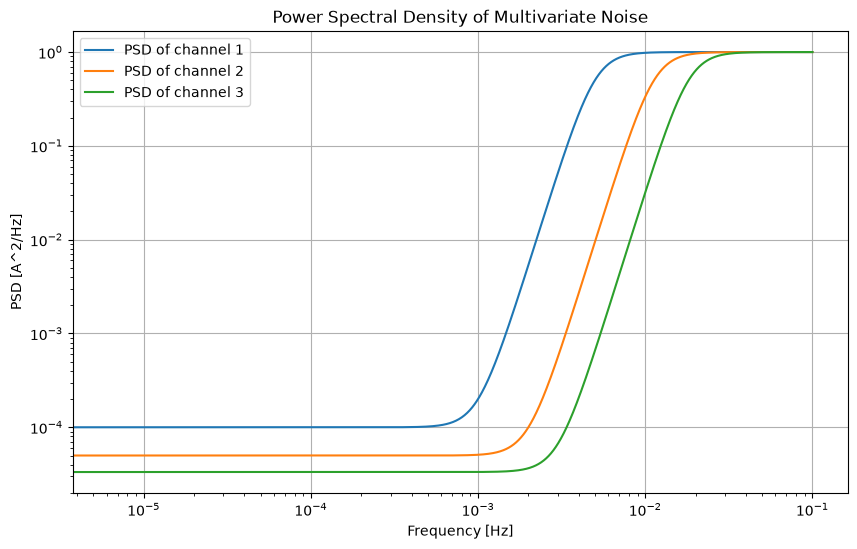

In [4]:
# Plot the PSD on positive frequencies
inds_pos = frequencies >= 0
positive_freqs = frequencies[inds_pos]
psd_matrix_positive = psd_matrix[inds_pos]
plt.figure(figsize=(10, 6))
for i in range(psd_matrix_positive.shape[1]):
    plt.loglog(positive_freqs, np.real(psd_matrix_positive[:, i, i]), label=f'PSD of channel {i+1}')
plt.title('Power Spectral Density of Multivariate Noise')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [A^2/Hz]')
plt.legend()
plt.grid()
plt.show()

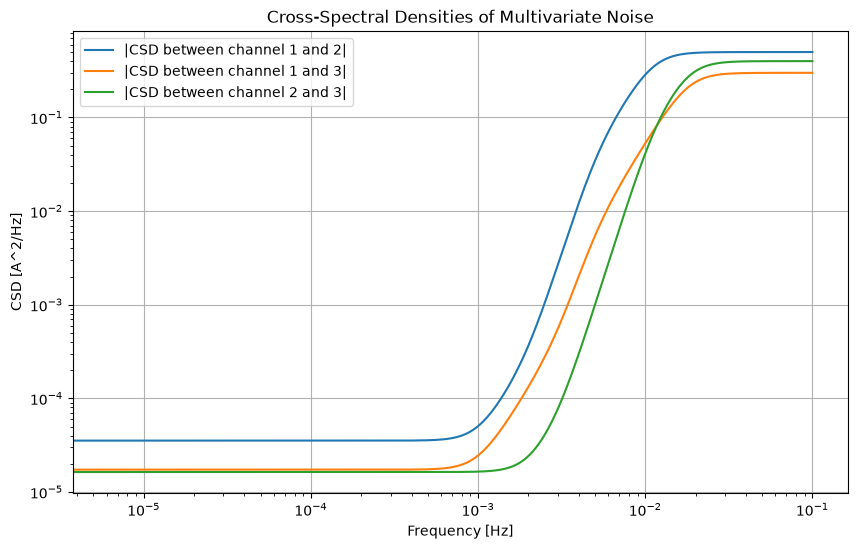

In [5]:
# Plot the absolute value of the cross-spectral densities
plt.figure(figsize=(10, 6))
plt.loglog(positive_freqs, np.abs(psd_matrix_positive[:, 0, 1]), label='|CSD between channel 1 and 2|')
plt.loglog(positive_freqs, np.abs(psd_matrix_positive[:, 0, 2]), label='|CSD between channel 1 and 3|')
plt.loglog(positive_freqs, np.abs(psd_matrix_positive[:, 1, 2]), label='|CSD between channel 2 and 3|')
plt.title('Cross-Spectral Densities of Multivariate Noise')
plt.xlabel('Frequency [Hz]')
plt.ylabel('CSD [A^2/Hz]')
plt.legend()
plt.grid()
plt.show()

In [6]:
# Generate Gaussian stationary noise
n = noisegenerator.generate_noise_from_psd(psd_matrix, fs, myseed=42)[0:n_data]

Then we need a deterministic signal to add. We choose a sinusoid with some frequency $f_0$ and amplitude $a_0$:

In [7]:
# Creation of deterministic signal
t = np.arange(0, n_data) / fs
f0 = 1e-3
a0 = 1e-3
s = np.asarray([a0 * np.sin(2 * np.pi * f0 * t + phi) for phi in [0, np.pi/4, np.pi/2]]).T
# Adding signal to noise
y = s + n

Now assume that some data are missing, i.e. the time series is cut by random gaps. The pattern is represented by a mask vector with entries equal to 1 when data is observed, and 0 otherwise:

In [8]:
mask = np.ones(n_data)
n_gaps = 30
# Fix the seed
np.random.seed(42)
gapstarts = (n_data * np.random.random(n_gaps)).astype(int)
gaplength = 10 #Gap is a fixed size in time.
gapends = (gapstarts+gaplength).astype(int)
for k in range(n_gaps): mask[gapstarts[k]:gapends[k]]= 0
# Masked data:
y_masked = mask[:, np.newaxis] * y

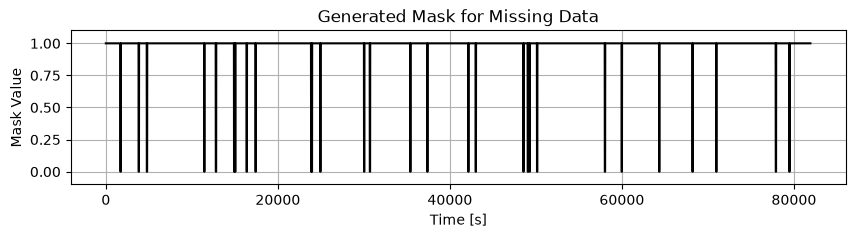

In [9]:
# Plot the generated mask
plt.figure(figsize=(10, 2))
plt.plot(t, mask, label='Mask', color='black')
plt.title('Generated Mask for Missing Data')
plt.xlabel('Time [s]')
plt.ylabel('Mask Value')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.show()

## 2. Define your PSD function and embed it in a class

## Check that the PSD function is consistent with the data

In [10]:
def compute_empirical_spectrum_matrix(y, fs):
    """
    Compute the empirical cross-spectral density matrix of a multivariate time series.

    Parameters
    ----------
    y : ndarray
        Multivariate time series data of shape (n_samples, n_channels).
    fs : float
        Sampling frequency in Hz.

    Returns
    -------
    f : ndarray
        Frequencies corresponding to the computed PSD values.
    psd_matrix : ndarray
        Empirical cross-spectral density matrix of shape (n_freqs, n_channels, n_channels).
    """
    n_samples, n_channels = y.shape
    # Compute the FFT of the multivariate time series
    y_fft = np.fft.rfft(y, axis=0)
    # Compute the frequencies corresponding to the FFT
    f = np.fft.rfftfreq(n_samples, d=1/fs)
    # Initialize the PSD matrix
    psd_matrix = np.zeros((len(f), n_channels, n_channels), dtype=complex)

    # Compute the cross-spectral density for each pair of channels
    for i in range(n_channels):
        for j in range(n_channels):
            psd_matrix[:, i, j] = (y_fft[:, i] * np.conj(y_fft[:, j]))

    return f, psd_matrix * 2 / (n_samples*fs)

/Users/qbaghi/Codes/bayesdawn/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/qbaghi/Codes/bayesdawn/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


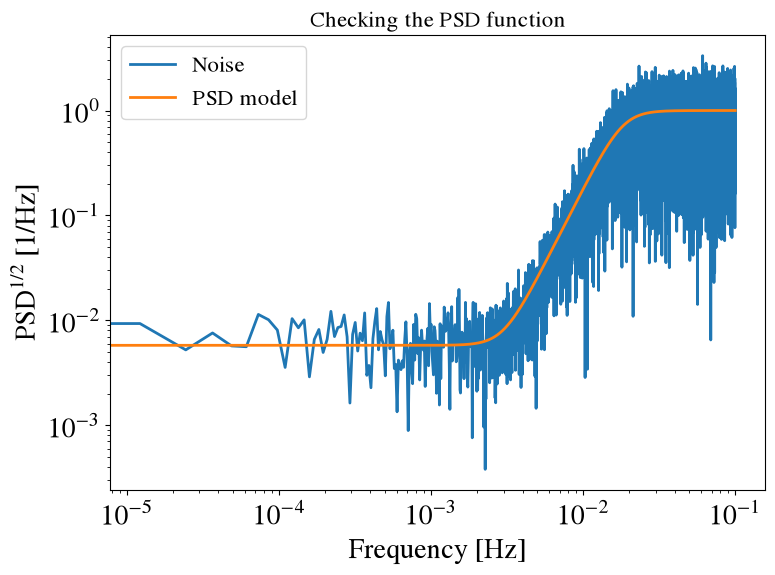

/Users/qbaghi/Codes/bayesdawn/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:853: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/Users/qbaghi/Codes/bayesdawn/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:896: ComplexWarning: Casting complex values to real discards the imaginary part
  db = np.array(np.diff(bin_edges), float)
/Users/qbaghi/Codes/bayesdawn/.venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7518: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


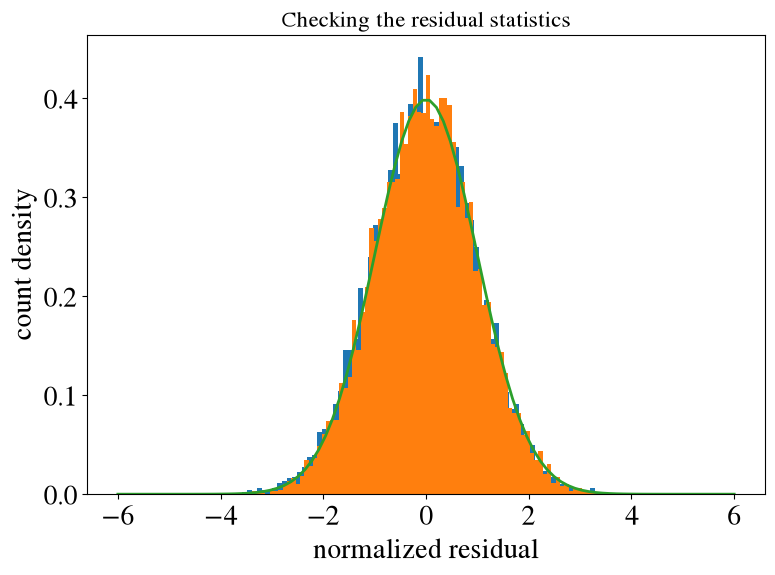

In [11]:
n_fft = np.fft.rfft(n, axis=0)
# Empirical PSD matrix
fr, periodogram_matrix = compute_empirical_spectrum_matrix(n, fs)
# Exact PSD matrix at the same frequencies
psd_matrix_fr = psd_function(fr, a1=a1, a2=a2, a3=a3)
# Positive frequency indices
inds_pos = fr >= 0

# Load plotting configuration
postprocess.plotconfig(lbsize=20,
                       lgsize=16, autolayout=True, figsize=(8, 6),
                       ticklabelsize=20)
# Select channel
j = 2
# Plot data against PSD
fig, ax = plt.subplots()
ax.set_title(r"Checking the PSD function")
ax.set_xlabel(r"Frequency [Hz]")
ax.set_ylabel(r"PSD${}^{1/2}$ [1/Hz]") 
ax.loglog(fr[inds_pos], np.sqrt(np.abs(periodogram_matrix[inds_pos, j, j])), label="Noise")
ax.loglog(fr[inds_pos], np.sqrt(psd_matrix_fr[inds_pos, j, j]), label="PSD model")
plt.legend()
plt.show()
#Check the statistics on the residual
df=fs/n_data
nbins=int(np.sqrt(len(n_fft)))
scalefac = np.sqrt(2 / (fs * n_data))
plt.hist(n_fft.real[inds_pos, j]*scalefac/np.sqrt(psd_matrix_fr[inds_pos, j, j]/2),bins=nbins,density=True,label="real part")
plt.hist(n_fft.imag[inds_pos, j]*scalefac/np.sqrt(psd_matrix_fr[inds_pos, j, j]/2),bins=nbins,density=True,label='imag part')
xf=np.linspace(-6,6,nbins)
plt.plot(xf,norm.pdf(xf))
plt.title(r"Checking the residual statistics")
plt.xlabel(r"normalized residual")
plt.ylabel(r"count density") 
plt.show()

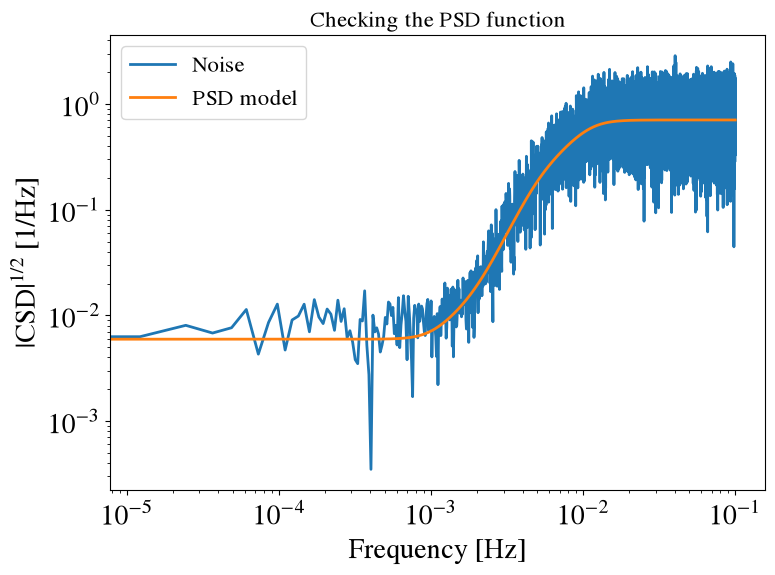

In [ ]:
# Compare the CSD of the generated noise with the model

fig, ax = plt.subplots()
ax.set_title(r"Checking the PSD function")
ax.set_xlabel(r"Frequency [Hz]")
ax.set_ylabel(r"|CSD|${}^{1/2}$ [1/Hz]")
ax.loglog(fr[inds_pos], np.sqrt(np.abs(periodogram_matrix[inds_pos, 0, 1])), label="Noise")
ax.loglog(fr[inds_pos], np.sqrt(np.abs(psd_matrix_fr[inds_pos, 0, 1])), label="CSD model")
plt.legend()
plt.show()

In [13]:
# Embed the PSD function in a class
class MyPSD(psdmodel.MultivariatePSD):

    def psd_fn(self, x):

        return psd_function(x)

In [14]:
# Instantiate the psd class
psd_cls = MyPSD(n_data, fs, n_chan=3)

## 3. Instantiate the imputation class

Then, from the signal and noise models, we can instantiate the GaussianStationaryProcess class from the datamodel module:

In [15]:
fs

0.2

In [16]:
# instantiate imputation class
imp_cls = datamodel.MultivariateGaussianStationaryProcess(s, mask, psd_cls, method='nearest',
                                                          na=50, nb=50)
# perform offline computations
imp_cls.compute_offline()
# If you want to update the deterministic signal (the mean of the Gaussian process)
imp_cls.update_mean(s)
# If you want to update the PSD model
imp_cls.update_psd(psd_cls)

## 4. Perform missing data imputation

We can then reconstruct the missing data with the `impute` method of the GaussianStationaryProcess class:

In [17]:
# Imputation of missing data by randomly drawing from their conditional distribution
y_rec_draw = imp_cls.impute(y_masked, draw=True)

In [18]:
# Imputation of missing data by evaluating the conditional mean of the missing data
y_rec = imp_cls.impute(y_masked, draw=False)

To see whether the imputation gives statisfactory statistics, we will compare the imputed data to the original one in Fourier domain. We start by Fourier-transforming the data:

In [19]:
# Fourier transform the results and the input data
y_fft = np.fft.rfft(y, axis=0)
y_masked_fft = np.fft.rfft(y_masked, axis=0)
y_rec_fft = np.fft.rfft(y_rec, axis=0)
y_rec_draw_fft = np.fft.rfft(y_rec_draw, axis=0)

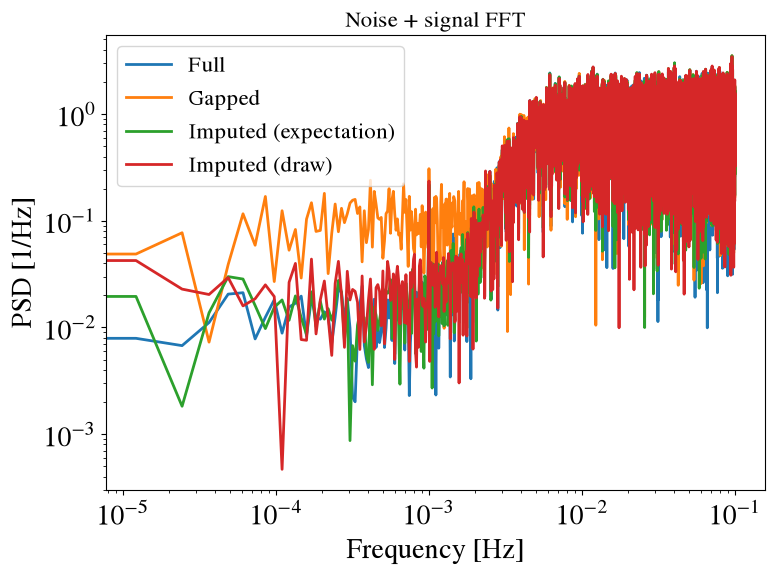

In [20]:
# Plot results
fig, ax = plt.subplots()
ax.set_title(r"Noise + signal FFT")
ax.set_xlabel(r"Frequency [Hz]")
ax.set_ylabel(r"PSD [1/Hz]")
# Channel index
j = 0
ax.loglog(fr[inds_pos], np.abs(y_fft[inds_pos, j]) * scalefac, label="Full")
ax.loglog(fr[inds_pos], np.abs(y_masked_fft[inds_pos, j]) * scalefac, label="Gapped")
ax.loglog(fr[inds_pos], np.abs(y_rec_fft[inds_pos, j]) * scalefac, label="Imputed (expectation)")
ax.loglog(fr[inds_pos], np.abs(y_rec_draw_fft[inds_pos, j]) * scalefac, label="Imputed (draw)")
plt.legend()
plt.show()

## 5. Comparing time series

0.9345949409730687


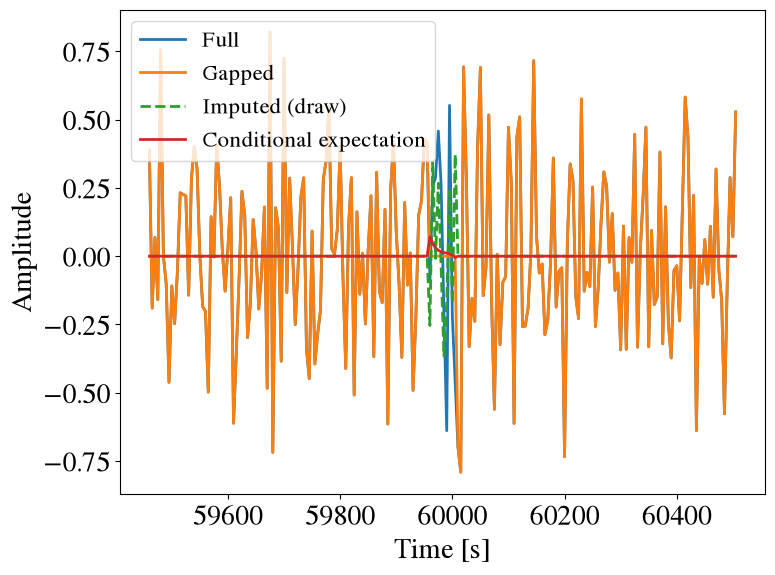

In [21]:
k = 2
delta = 100
inds = np.arange(gapstarts[k]-delta, gapends[k]+delta)
ym = y * (1 - mask[:, np.newaxis])
ym_rec_draw = y_rec_draw * (1 - mask[:, np.newaxis])
var_rec_draw = np.var(ym_rec_draw[mask==0])
var_original = np.var(ym[mask==0])
print(var_rec_draw / var_original)

# Select channel
j = 0
fig, ax = plt.subplots()
# ax.set_title(r"Noise + signal FFT")
ax.set_xlabel(r"Time [s]")
ax.set_ylabel(r"Amplitude") 
ax.plot(t[inds], y[inds, j], label="Full")
ax.plot(t[inds], y_masked[inds, j], label="Gapped")
ax.plot(t[inds], ym_rec_draw[inds, j], label="Imputed (draw)", linestyle='dashed')
ax.plot(t[inds], y_rec[inds, j]* (1 - mask[inds]), label="Conditional expectation")
plt.legend()
plt.show()